# EDA — Dataset 113: Clasificación de Peso (`clas_peso`)

---
## Contenido
1. Carga y resumen general
2. Distribución de `clas_peso`
3. Análisis por edad
4. Análisis por sexo
5. Análisis por año
6. Análisis por municipio
7. Correlación de variables con `clas_peso`
8. Estadísticas descriptivas detalladas por clase de peso

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

# Paleta de colores consistente en todo el notebook
COLORES_CLASE = {
    'Desnut. severa'   : '#c0392b',
    'Desnut. moderada' : '#e67e22',
    'Normal'           : '#27ae60',
    'Riesgo sobrepeso' : '#2980b9',
    'Sobrepeso'        : '#8e44ad',
    'Obesidad'         : '#16a085'
}
ORDEN = list(COLORES_CLASE.keys())
COLORES_LISTA = list(COLORES_CLASE.values())

---
## 1. Carga y resumen general

In [3]:
# Ajusta la ruta si es necesario
df = pd.read_csv('../data/processed/113_limpio_unificado.csv')

# Mapeo de etiquetas
MAPA_PESO = {
    1: 'Desnut. severa',
    2: 'Desnut. moderada',
    3: 'Normal',
    4: 'Riesgo sobrepeso',
    5: 'Sobrepeso',
    6: 'Obesidad'
}
df['clas_peso_label'] = df['clas_peso'].map(MAPA_PESO)

print(f'Registros totales : {len(df):,}')
print(f'Columnas          : {df.shape[1]}')
print(f'Años              : {sorted(df["anio"].unique())}')
print(f'Municipios únicos : {df["municipio_origen"].nunique()}')
print()

print('Nulos en columnas clave:')
cols_clave = ['clas_peso', 'peso_nac', 'talla_nac', 'edad_ges', 'peso_act',
              'talla_act', 'per_braqui', 'imc', 'zscore_pt', 'zscore_te']
print(df[cols_clave].isnull().sum().rename('Nulos').to_string())

Registros totales : 2,448
Columnas          : 37
Años              : [np.int64(2023), np.int64(2024), np.int64(2025)]
Municipios únicos : 36

Nulos en columnas clave:
clas_peso        9
peso_nac         0
talla_nac     1510
edad_ges         0
peso_act         0
talla_act        0
per_braqui     228
imc              0
zscore_pt        0
zscore_te        0


---
## 2. Distribución de `clas_peso`

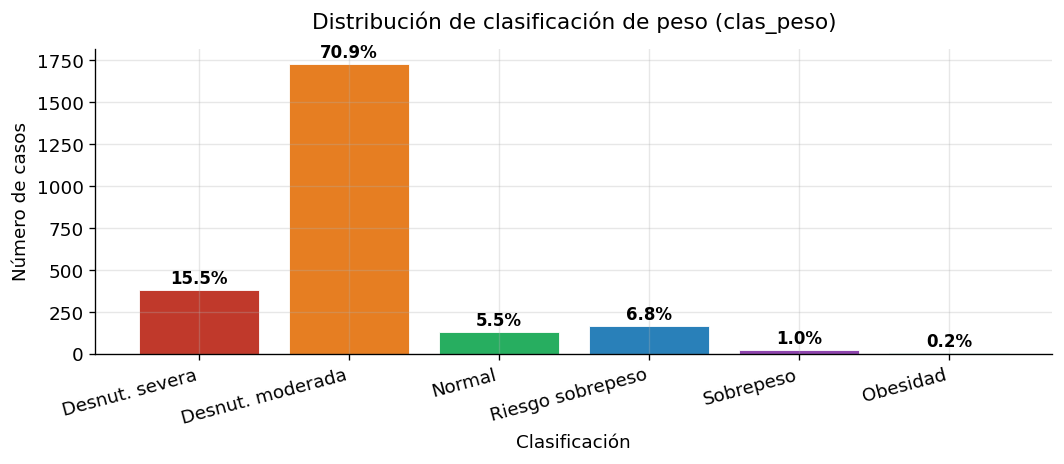


Resumen:
                  Casos  Porcentaje (%)
clas_peso_label                        
Desnut. severa      379           15.54
Desnut. moderada   1730           70.93
Normal              133            5.45
Riesgo sobrepeso    167            6.85
Sobrepeso            24            0.98
Obesidad              6            0.25

⚠  Desbalance: 86.5% con algún tipo de desnutrición
   Normal + otras categorías: 13.5%


In [4]:
conteo     = df['clas_peso_label'].value_counts().reindex(ORDEN)
porcentaje = conteo / conteo.sum() * 100

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(ORDEN, conteo.values, color=COLORES_LISTA, edgecolor='white', linewidth=0.5)

for bar, pct in zip(bars, porcentaje.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Distribución de clasificación de peso (clas_peso)', fontsize=13, pad=12)
ax.set_xlabel('Clasificación')
ax.set_ylabel('Número de casos')
ax.set_xticklabels(ORDEN, rotation=15, ha='right')
plt.tight_layout()
plt.show()

print('\nResumen:')
resumen = pd.DataFrame({'Casos': conteo, 'Porcentaje (%)': porcentaje.round(2)})
print(resumen.to_string())

pct_desnut = porcentaje['Desnut. severa'] + porcentaje['Desnut. moderada']
print(f'\n⚠  Desbalance: {pct_desnut:.1f}% con algún tipo de desnutrición')
print(f'   Normal + otras categorías: {100 - pct_desnut:.1f}%')

---
## 3. Análisis por edad

In [5]:
# Convertir todo a meses para uniformidad
# uni_med_ = 1 -> años, uni_med_ = 2 -> meses
df['edad_meses'] = df.apply(
    lambda r: r['edad_'] * 12 if r['uni_med_'] == 1 else r['edad_'],
    axis=1
)

# Grupos etarios estándar OMS para menores de 5 años
bins   = [0, 5, 11, 23, 35, 47, 60]
labels = ['0-5m', '6-11m', '12-23m', '24-35m', '36-47m', '48-59m']
df['grupo_edad'] = pd.cut(df['edad_meses'], bins=bins, labels=labels, right=True)

print('Distribución general por grupo etario:')
ge = df['grupo_edad'].value_counts().sort_index()
pct_ge = ge / ge.sum() * 100
print(pd.DataFrame({'Casos': ge, 'Porcentaje (%)': pct_ge.round(2)}).to_string())

Distribución general por grupo etario:
            Casos  Porcentaje (%)
grupo_edad                       
0-5m          183            7.48
6-11m         435           17.77
12-23m       1133           46.28
24-35m        375           15.32
36-47m        177            7.23
48-59m        145            5.92


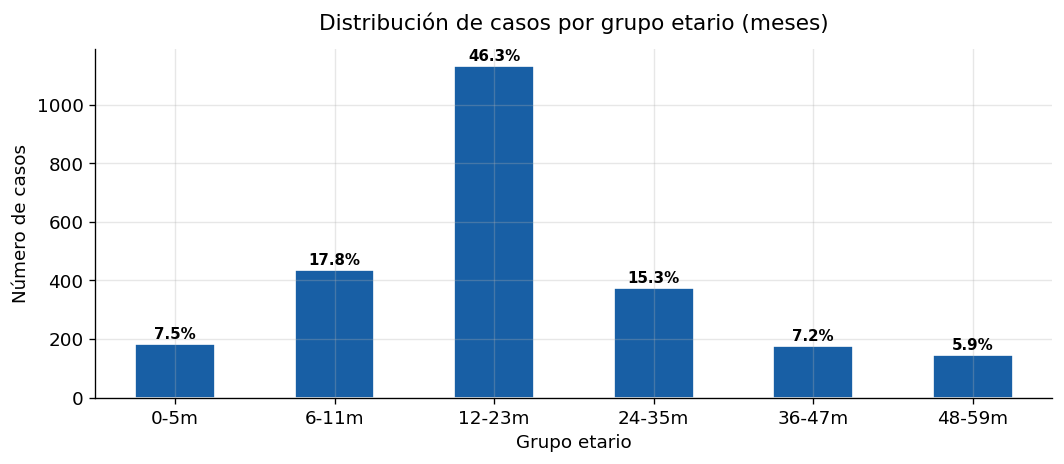

In [6]:
# --- 3a. Distribución de casos por grupo etario ---
fig, ax = plt.subplots(figsize=(9, 4))
ge.plot(kind='bar', ax=ax, color='#185fa5', edgecolor='white')

for p, v in zip(ax.patches, pct_ge.values):
    ax.text(p.get_x() + p.get_width() / 2, p.get_height() + 8,
            f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Distribución de casos por grupo etario (meses)', fontsize=13, pad=12)
ax.set_xlabel('Grupo etario')
ax.set_ylabel('Número de casos')
ax.set_xticklabels(labels, rotation=0)
plt.tight_layout()
plt.show()

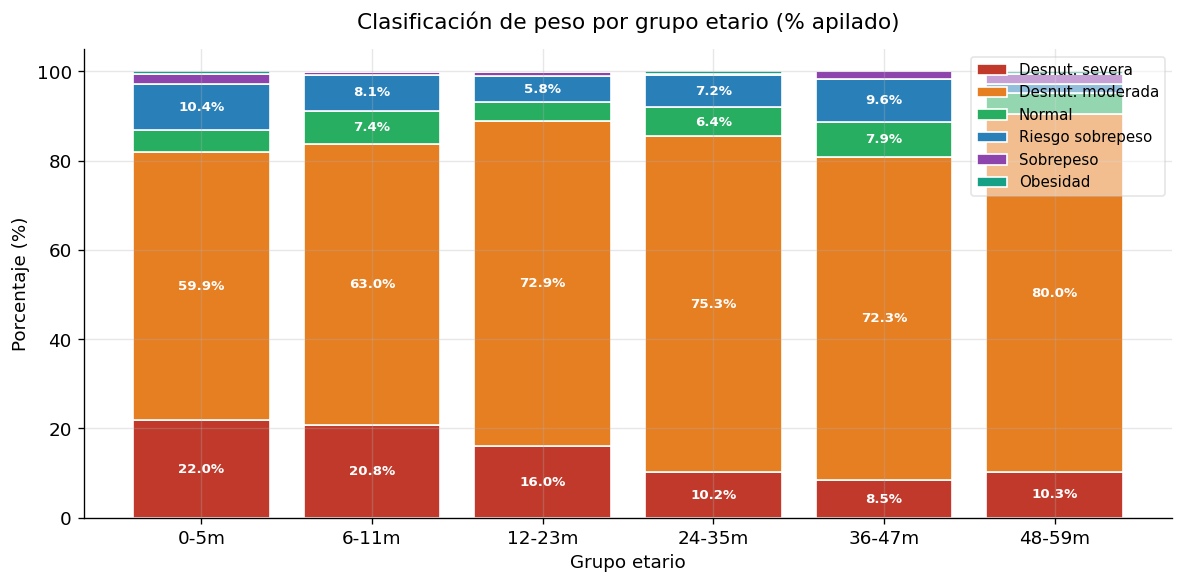


Tabla: % de clas_peso por grupo etario
clas_peso_label  Desnut. severa  Desnut. moderada  Normal  Riesgo sobrepeso  Sobrepeso  Obesidad
grupo_edad                                                                                      
0-5m                      21.98             59.89    4.95             10.44       2.20      0.55
6-11m                     20.79             63.05    7.39              8.08       0.46      0.23
12-23m                    16.03             72.90    4.16              5.85       0.97      0.09
24-35m                    10.19             75.34    6.43              7.24       0.27      0.54
36-47m                     8.47             72.32    7.91              9.60       1.69      0.00
48-59m                    10.34             80.00    4.83              2.07       2.07      0.69


In [7]:
# --- 3b. Clasificación de peso por grupo etario (barras apiladas 100%) ---
tabla_edad = pd.crosstab(df['grupo_edad'], df['clas_peso_label'])
tabla_edad = tabla_edad.reindex(columns=ORDEN, fill_value=0)
tabla_pct  = tabla_edad.div(tabla_edad.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(tabla_pct))

for col, color in zip(ORDEN, COLORES_LISTA):
    vals = tabla_pct[col].values
    bars = ax.bar(tabla_pct.index.astype(str), vals, bottom=bottom,
                  color=color, edgecolor='white', label=col)
    # Etiquetas solo si > 5%
    for bar, v in zip(bars, vals):
        if v > 5:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f'{v:.1f}%', ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    bottom += vals

ax.set_title('Clasificación de peso por grupo etario (% apilado)', fontsize=13, pad=12)
ax.set_xlabel('Grupo etario')
ax.set_ylabel('Porcentaje (%)')
ax.set_ylim(0, 105)
ax.legend(loc='upper right', framealpha=0.5, fontsize=9)
plt.tight_layout()
plt.show()

print('\nTabla: % de clas_peso por grupo etario')
print(tabla_pct.round(2).to_string())

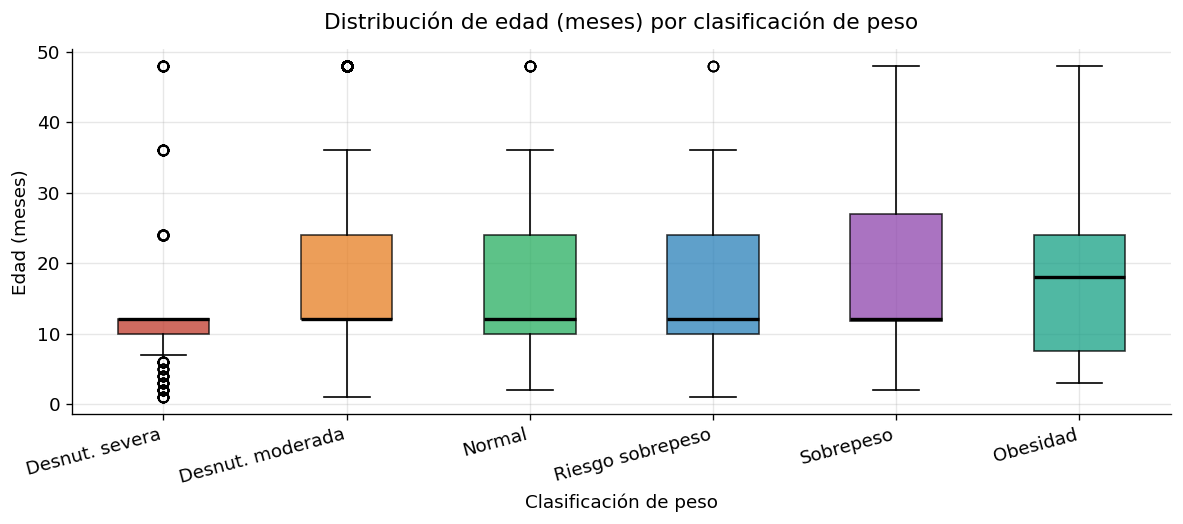


Mediana de edad (meses) por clase:
clas_peso_label
Desnut. severa      12.0
Desnut. moderada    12.0
Normal              12.0
Riesgo sobrepeso    12.0
Sobrepeso           12.0
Obesidad            18.0


In [8]:
# --- 3c. Boxplot edad (meses) por clasificación de peso ---
grupos_edad = [df.loc[df['clas_peso_label'] == c, 'edad_meses'].dropna().values
               for c in ORDEN]

fig, ax = plt.subplots(figsize=(10, 4.5))
bp = ax.boxplot(grupos_edad, patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=2))

for patch, color in zip(bp['boxes'], COLORES_LISTA):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_xticks(range(1, len(ORDEN) + 1))
ax.set_xticklabels(ORDEN, rotation=15, ha='right')
ax.set_title('Distribución de edad (meses) por clasificación de peso', fontsize=13, pad=12)
ax.set_xlabel('Clasificación de peso')
ax.set_ylabel('Edad (meses)')
plt.tight_layout()
plt.show()

print('\nMediana de edad (meses) por clase:')
print(df.groupby('clas_peso_label')['edad_meses'].median().reindex(ORDEN).round(1).to_string())

---
## 4. Análisis por sexo

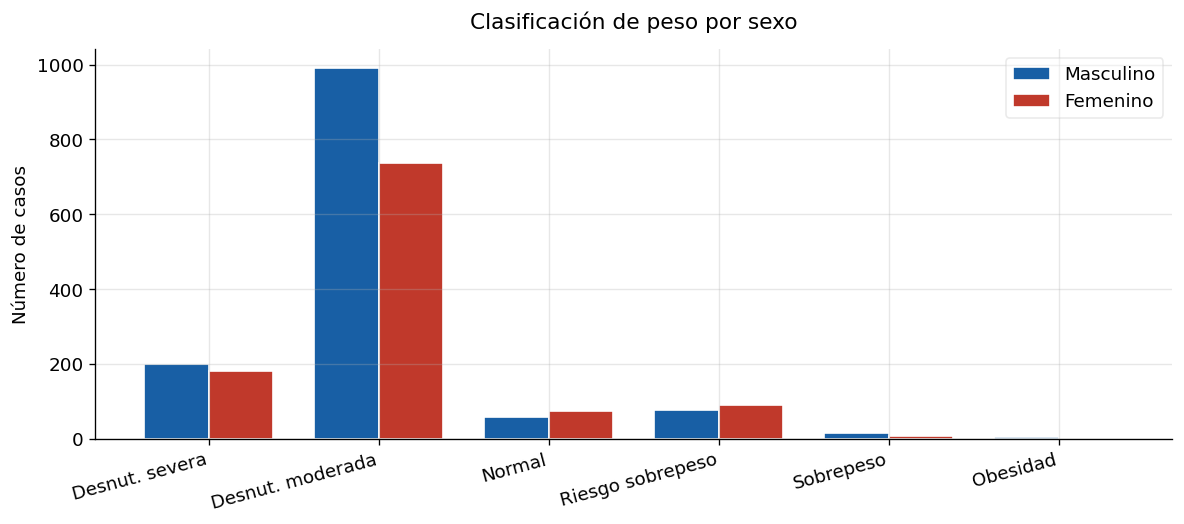

Tabla absoluta:
sexo_               F    M
clas_peso_label           
Desnut. severa    180  199
Desnut. moderada  738  992
Normal             74   59
Riesgo sobrepeso   91   76
Sobrepeso           8   16
Obesidad            0    6

Tabla porcentual por sexo:
sexo_                 F      M
clas_peso_label               
Desnut. severa    16.50  14.76
Desnut. moderada  67.64  73.59
Normal             6.78   4.38
Riesgo sobrepeso   8.34   5.64
Sobrepeso          0.73   1.19
Obesidad           0.00   0.45


In [9]:
tabla_sexo = pd.crosstab(df['clas_peso_label'], df['sexo_']).reindex(ORDEN)

x     = np.arange(len(ORDEN))
width = 0.38

fig, ax = plt.subplots(figsize=(10, 4.5))
b_m = ax.bar(x - width / 2, tabla_sexo.get('M', 0), width,
             label='Masculino', color='#185fa5', edgecolor='white')
b_f = ax.bar(x + width / 2, tabla_sexo.get('F', 0), width,
             label='Femenino',  color='#c0392b', edgecolor='white')

ax.set_title('Clasificación de peso por sexo', fontsize=13, pad=12)
ax.set_xticks(x)
ax.set_xticklabels(ORDEN, rotation=15, ha='right')
ax.set_ylabel('Número de casos')
ax.legend(framealpha=0.4)
plt.tight_layout()
plt.show()

print('Tabla absoluta:')
print(tabla_sexo.to_string())

print('\nTabla porcentual por sexo:')
tabla_sexo_pct = tabla_sexo.div(tabla_sexo.sum(axis=0), axis=1) * 100
print(tabla_sexo_pct.round(2).to_string())

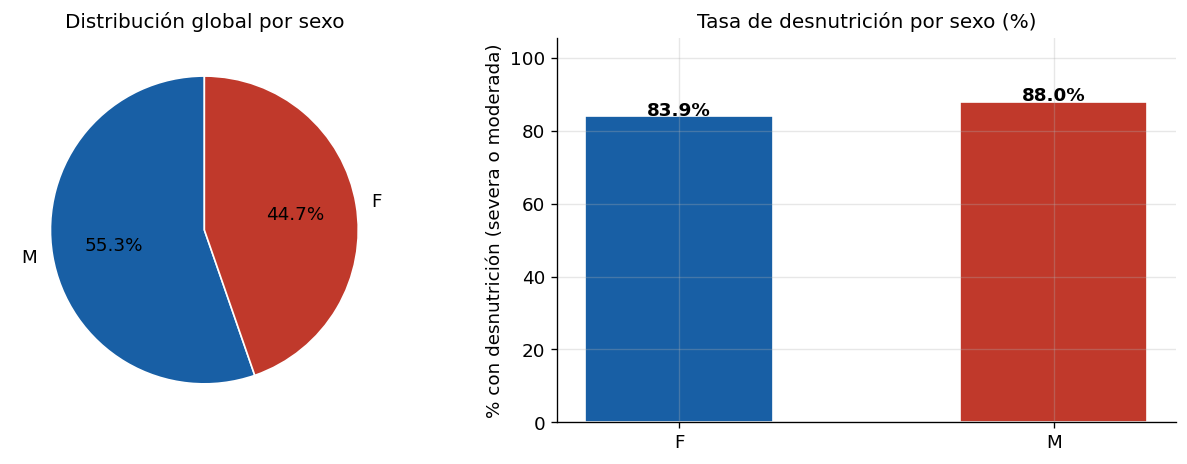

In [10]:
# --- 4b. Proporción global M / F ---
sexo_conteo = df['sexo_'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Pie general
axes[0].pie(sexo_conteo.values, labels=sexo_conteo.index,
            autopct='%1.1f%%', colors=['#185fa5', '#c0392b'],
            startangle=90, wedgeprops=dict(edgecolor='white'))
axes[0].set_title('Distribución global por sexo', fontsize=12)

# Tasa de desnutrición (severa+moderada) por sexo
df['desnutrido'] = df['clas_peso'].isin([1, 2])
tasa_desnut = df.groupby('sexo_')['desnutrido'].mean() * 100

axes[1].bar(tasa_desnut.index, tasa_desnut.values,
            color=['#185fa5', '#c0392b'], edgecolor='white', width=0.5)
for i, (idx, val) in enumerate(tasa_desnut.items()):
    axes[1].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Tasa de desnutrición por sexo (%)', fontsize=12)
axes[1].set_ylabel('% con desnutrición (severa o moderada)')
axes[1].set_ylim(0, tasa_desnut.max() * 1.2)

plt.tight_layout()
plt.show()

---
## 5. Análisis por año

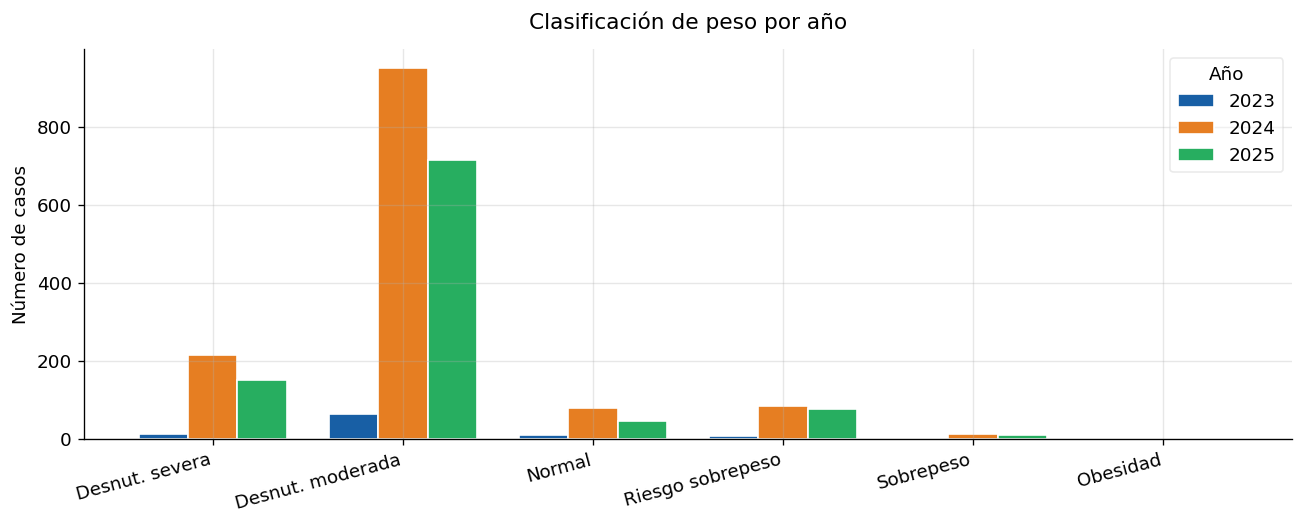

Tabla absoluta por año:
anio              2023  2024  2025
clas_peso_label                   
Desnut. severa      13   215   151
Desnut. moderada    64   951   715
Normal               9    78    46
Riesgo sobrepeso     7    84    76
Sobrepeso            3    11    10
Obesidad             1     2     3


In [11]:
anios         = sorted(df['anio'].unique())
tabla_anio    = pd.crosstab(df['clas_peso_label'], df['anio']).reindex(ORDEN)
colores_anio  = ['#185fa5', '#e67e22', '#27ae60']

x     = np.arange(len(ORDEN))
width = 0.26
n_anios = len(anios)

fig, ax = plt.subplots(figsize=(11, 4.5))
for i, (anio, color) in enumerate(zip(anios, colores_anio)):
    offset = (i - (n_anios - 1) / 2) * width
    ax.bar(x + offset, tabla_anio.get(anio, 0), width,
           label=str(anio), color=color, edgecolor='white')

ax.set_title('Clasificación de peso por año', fontsize=13, pad=12)
ax.set_xticks(x)
ax.set_xticklabels(ORDEN, rotation=15, ha='right')
ax.set_ylabel('Número de casos')
ax.legend(title='Año', framealpha=0.4)
plt.tight_layout()
plt.show()

print('Tabla absoluta por año:')
print(tabla_anio.to_string())

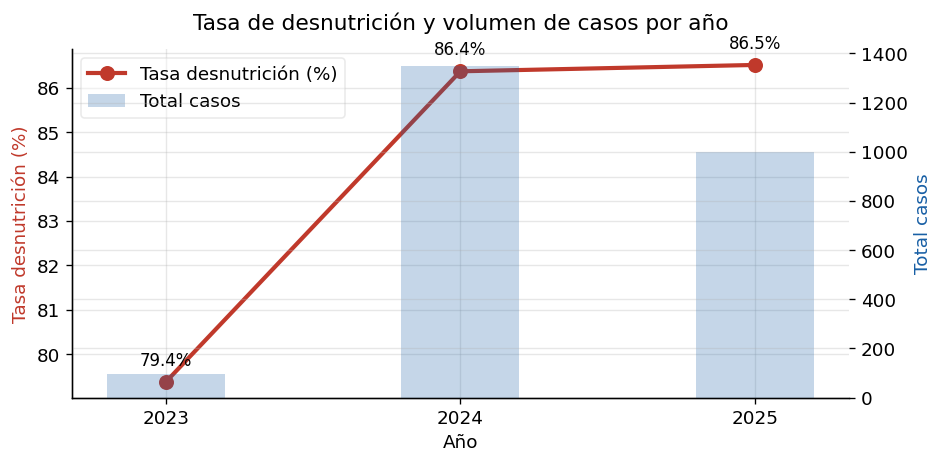

Total de casos por año:
anio
2023      97
2024    1350
2025    1001

Tasa de desnutrición por año (%):
anio
2023    79.38
2024    86.37
2025    86.51


In [12]:
# --- 5b. Tendencia de tasa de desnutrición por año ---
tasa_anio = df.groupby('anio')['desnutrido'].mean() * 100
total_anio = df.groupby('anio').size()

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()

ax1.plot(tasa_anio.index, tasa_anio.values, 'o-', color='#c0392b',
         linewidth=2.5, markersize=8, label='Tasa desnutrición (%)')
for x_val, y_val in zip(tasa_anio.index, tasa_anio.values):
    ax1.annotate(f'{y_val:.1f}%', (x_val, y_val),
                 textcoords='offset points', xytext=(0, 10), ha='center', fontsize=10)

ax2.bar(total_anio.index, total_anio.values, color='#185fa5',
        alpha=0.25, width=0.4, label='Total casos')

ax1.set_title('Tasa de desnutrición y volumen de casos por año', fontsize=13, pad=12)
ax1.set_xlabel('Año')
ax1.set_ylabel('Tasa desnutrición (%)', color='#c0392b')
ax2.set_ylabel('Total casos', color='#185fa5')
ax1.set_xticks(anios)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', framealpha=0.4)

plt.tight_layout()
plt.show()

print('Total de casos por año:')
print(total_anio.to_string())
print('\nTasa de desnutrición por año (%):')
print(tasa_anio.round(2).to_string())

---
## 6. Análisis por municipio

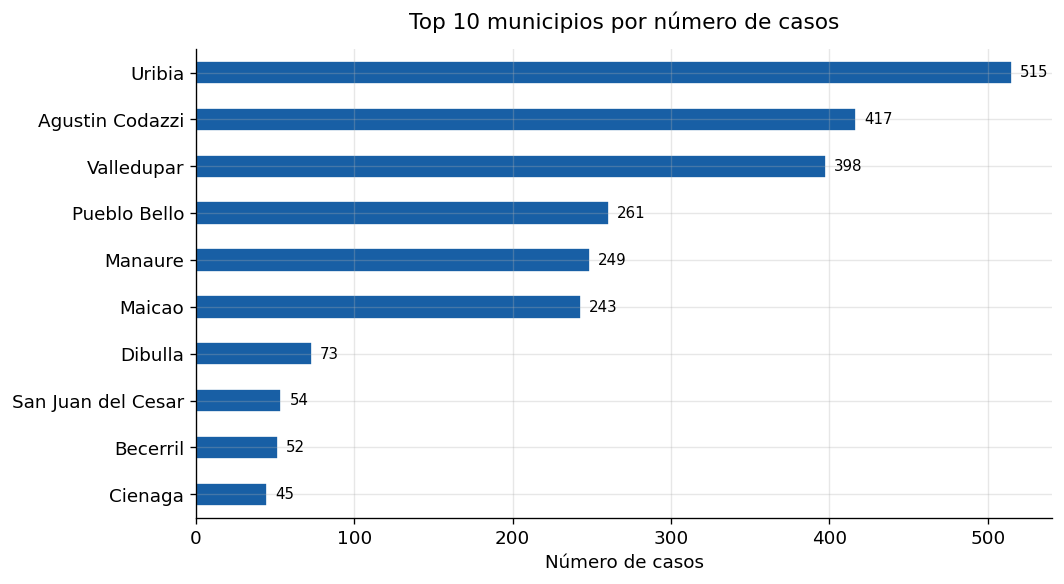

In [13]:
# --- 6a. Top 10 municipios por número de casos ---
top10_mun = df['municipio_origen'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(9, 5))
top10_mun[::-1].plot(kind='barh', ax=ax, color='#185fa5', edgecolor='white')

for p in ax.patches:
    ax.text(p.get_width() + 5, p.get_y() + p.get_height() / 2,
            f'{int(p.get_width()):,}', va='center', fontsize=9)

ax.set_title('Top 10 municipios por número de casos', fontsize=13, pad=12)
ax.set_xlabel('Número de casos')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

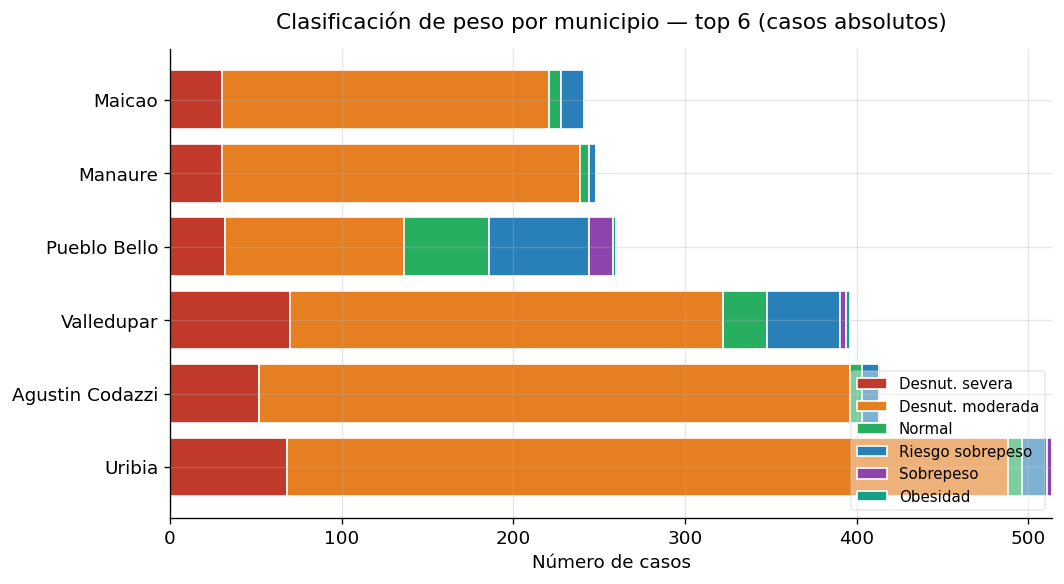

Tabla absoluta:
clas_peso_label   Desnut. severa  Desnut. moderada  Normal  Riesgo sobrepeso  Sobrepeso  Obesidad
municipio_origen                                                                                 
Uribia                        68               420       8                15          3         0
Agustin Codazzi               52               344       7                10          1         1
Valledupar                    70               252      26                42          4         2
Pueblo Bello                  32               104      50                58         14         2
Manaure                       30               209       5                 4          0         0
Maicao                        30               191       7                13          1         0


In [14]:
# --- 6b. Distribución de clas_peso por municipio (top 6, barras apiladas absolutas) ---
top6_mun  = df['municipio_origen'].value_counts().head(6).index.tolist()
df_mun    = df[df['municipio_origen'].isin(top6_mun)].copy()

tabla_mun = pd.crosstab(df_mun['municipio_origen'], df_mun['clas_peso_label'])
tabla_mun = tabla_mun.reindex(columns=ORDEN, fill_value=0).loc[top6_mun]

fig, ax = plt.subplots(figsize=(9, 5))
left = np.zeros(len(tabla_mun))
for col, color in zip(ORDEN, COLORES_LISTA):
    ax.barh(tabla_mun.index, tabla_mun[col], left=left,
            color=color, edgecolor='white', label=col)
    left += tabla_mun[col].values

ax.set_title('Clasificación de peso por municipio — top 6 (casos absolutos)', fontsize=13, pad=12)
ax.set_xlabel('Número de casos')
ax.legend(loc='lower right', framealpha=0.4, fontsize=9)
plt.tight_layout()
plt.show()

print('Tabla absoluta:')
print(tabla_mun.to_string())

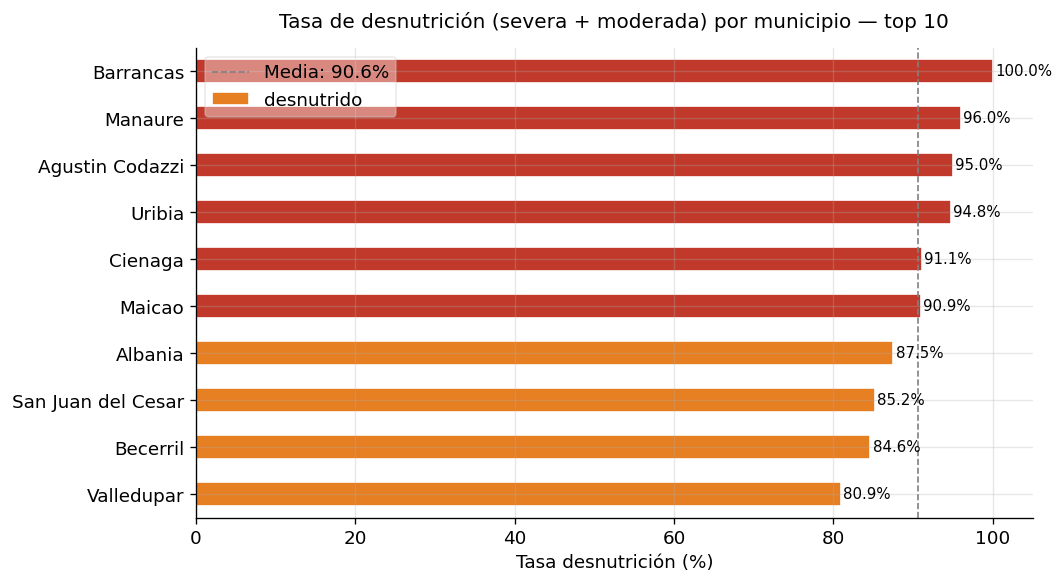

Tasa de desnutrición (%) — top 10 municipios:
municipio_origen
Barrancas             100.00
Manaure                95.98
Agustin Codazzi        94.96
Uribia                 94.76
Cienaga                91.11
Maicao                 90.95
Albania                87.50
San Juan del Cesar     85.19
Becerril               84.62
Valledupar             80.90


In [15]:
# --- 6c. Tasa de desnutrición por municipio (top 10) ---

# CAMBIO: filtrar municipios con al menos 20 casos
MIN_CASOS = 20
conteo_mun = df.groupby('municipio_origen').size()
mun_validos = conteo_mun[conteo_mun >= MIN_CASOS].index

tasa_mun = (df[df['municipio_origen'].isin(mun_validos)]
            .groupby('municipio_origen')['desnutrido']
            .mean()
            .mul(100)
            .sort_values(ascending=False))

tasa_mun_top10 = tasa_mun.head(10)  # ya viene ordenado, no necesita sort_values de nuevo

# --- todo lo de abajo queda exactamente igual ---
fig, ax = plt.subplots(figsize=(9, 5))
colores_bar = ['#c0392b' if v >= tasa_mun_top10.mean() else '#e67e22'
               for v in tasa_mun_top10.values]
tasa_mun_top10[::-1].plot(kind='barh', ax=ax, color=colores_bar[::-1], edgecolor='white')

for p in ax.patches:
    ax.text(p.get_width() + 0.3, p.get_y() + p.get_height() / 2,
            f'{p.get_width():.1f}%', va='center', fontsize=9)

ax.axvline(tasa_mun_top10.mean(), color='gray', linestyle='--', linewidth=1, label=f'Media: {tasa_mun_top10.mean():.1f}%')
ax.set_title('Tasa de desnutrición (severa + moderada) por municipio — top 10', fontsize=12, pad=12)
ax.set_xlabel('Tasa desnutrición (%)')
ax.set_ylabel('')
ax.legend(framealpha=0.4)
plt.tight_layout()
plt.show()

print('Tasa de desnutrición (%) — top 10 municipios:')
print(tasa_mun_top10.round(2).to_string())

---
## 7. Correlación de variables con `clas_peso`

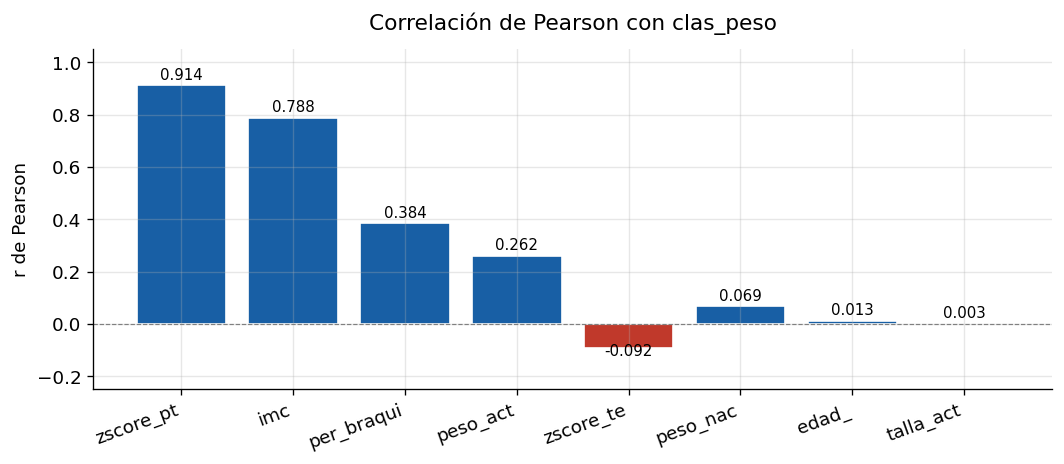


Correlaciones ordenadas:
zscore_pt     0.9136
imc           0.7883
per_braqui    0.3840
peso_act      0.2617
zscore_te    -0.0920
peso_nac      0.0695
edad_         0.0126
talla_act     0.0035


In [16]:
# --- 7a. Correlación de Pearson ---
num_cols = ['zscore_pt', 'imc', 'per_braqui', 'peso_act',
            'peso_nac', 'zscore_te', 'edad_', 'talla_act']
corr = (df[num_cols + ['clas_peso']]
        .corr()['clas_peso']
        .drop('clas_peso')
        .sort_values(key=abs, ascending=False))

colores_corr = ['#185fa5' if v >= 0 else '#c0392b' for v in corr.values]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(corr.index, corr.values, color=colores_corr, edgecolor='white')

for bar, val in zip(bars, corr.values):
    y = bar.get_height() + 0.01 if val >= 0 else bar.get_height() - 0.04
    ax.text(bar.get_x() + bar.get_width() / 2, y,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
ax.set_title('Correlación de Pearson con clas_peso', fontsize=13, pad=12)
ax.set_ylabel('r de Pearson')
ax.set_ylim(-0.25, 1.05)
ax.set_xticklabels(corr.index, rotation=20, ha='right')
plt.tight_layout()
plt.show()

print('\nCorrelaciones ordenadas:')
print(corr.round(4).to_string())

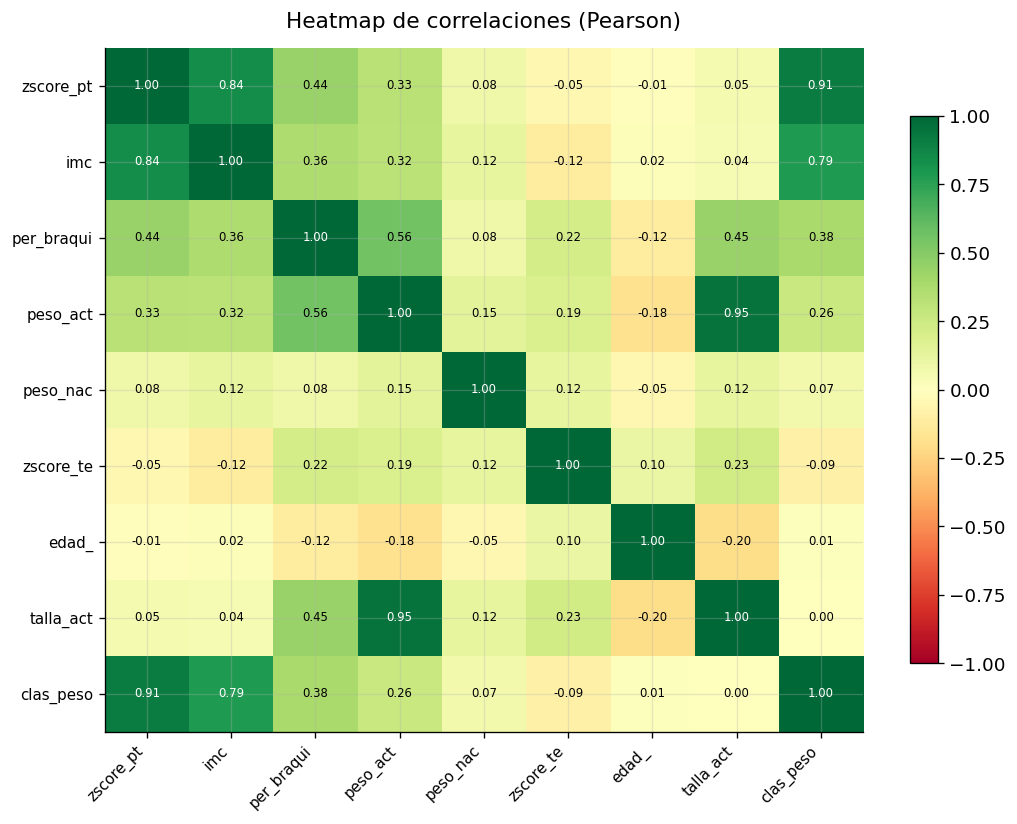

In [17]:
# --- 7b. Heatmap de correlaciones entre variables numéricas ---
cols_heatmap = num_cols + ['clas_peso']
corr_matrix  = df[cols_heatmap].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)

ax.set_xticks(range(len(cols_heatmap)))
ax.set_yticks(range(len(cols_heatmap)))
ax.set_xticklabels(cols_heatmap, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(cols_heatmap, fontsize=9)

for i in range(len(cols_heatmap)):
    for j in range(len(cols_heatmap)):
        val = corr_matrix.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7,
                color='black' if abs(val) < 0.7 else 'white')

ax.set_title('Heatmap de correlaciones (Pearson)', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

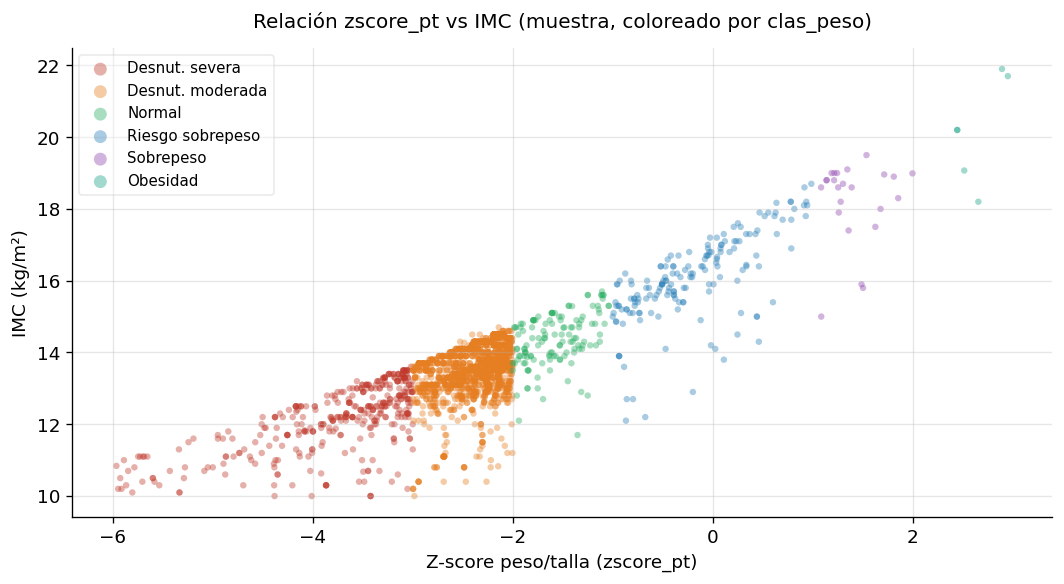

In [18]:
# --- 7c. Scatter zscore_pt vs imc coloreado por clas_peso ---
sample = df.dropna(subset=['zscore_pt', 'imc', 'clas_peso_label'])
# Limitar muestra para velocidad
if len(sample) > 5000:
    sample = sample.sample(5000, random_state=42)

fig, ax = plt.subplots(figsize=(9, 5))
for clase, color in COLORES_CLASE.items():
    sub = sample[sample['clas_peso_label'] == clase]
    ax.scatter(sub['zscore_pt'], sub['imc'], c=color, alpha=0.4,
               s=15, label=clase, edgecolors='none')

ax.set_title('Relación zscore_pt vs IMC (muestra, coloreado por clas_peso)', fontsize=12, pad=12)
ax.set_xlabel('Z-score peso/talla (zscore_pt)')
ax.set_ylabel('IMC (kg/m²)')
ax.legend(markerscale=2, framealpha=0.4, fontsize=9)
plt.tight_layout()
plt.show()

---
## 8. Estadísticas descriptivas detalladas por clase de peso

In [19]:
# --- 8a. Medias de variables clínicas por clase ---
cols_desc = ['edad_meses', 'peso_nac', 'talla_nac', 'edad_ges',
             'peso_act', 'talla_act', 'per_braqui', 'imc', 'zscore_pt', 'zscore_te']

medias = df.groupby('clas_peso_label')[cols_desc].mean().reindex(ORDEN).round(2)
print('Medias por clase de peso:')
print(medias.to_string())

Medias por clase de peso:
                  edad_meses  peso_nac  talla_nac  edad_ges  peso_act  talla_act  per_braqui    imc  zscore_pt  zscore_te
clas_peso_label                                                                                                          
Desnut. severa         13.82   2709.70      47.71     38.15      6.03      69.75       11.41  12.15      -3.75      -2.92
Desnut. moderada       17.10   2779.10      48.67     38.50      7.55      74.09       12.35  13.52      -2.38      -2.65
Normal                 17.29   2736.84      48.00     38.36      7.50      71.65       12.45  14.35      -1.58      -3.29
Riesgo sobrepeso       15.45   2810.19      47.64     38.82      8.04      69.96       13.36  16.04      -0.20      -3.33
Sobrepeso              18.33   2851.33      46.67     38.58      9.97      72.57       14.56  18.22       1.41      -3.64
Obesidad               19.50   3007.83      48.00     39.17     11.88      75.42       14.33  20.21       2.65      -2.6

In [20]:
# --- 8b. Estadísticas completas (mean, std, min, 25%, 50%, 75%, max) por clase ---
for clase in ORDEN:
    sub = df[df['clas_peso_label'] == clase][cols_desc]
    print(f'\n{'='*60}')
    print(f'  {clase.upper()}  —  {len(sub):,} registros')
    print(f'{'='*60}')
    print(sub.describe().round(3).to_string())


  DESNUT. SEVERA  —  379 registros
       edad_meses  peso_nac  talla_nac  edad_ges  peso_act  talla_act  per_braqui      imc  zscore_pt  zscore_te
count     379.000   379.000    161.000   379.000   379.000    379.000     328.000  379.000    379.000    379.000
mean       13.823  2709.698     47.708    38.148     6.033     69.751      11.406   12.154     -3.747     -2.917
std         9.901   389.497      3.535     2.012     1.654      9.213       1.294    0.917      0.719      1.693
min         1.000  1050.000     37.000    27.000     2.500     49.500       8.000   10.000     -5.964     -5.996
25%        10.000  2555.000     46.000    38.000     5.000     65.000      10.500   11.600     -4.091     -4.021
50%        12.000  2800.000     49.000    39.000     6.000     69.000      11.300   12.300     -3.504     -3.095
75%        12.000  2845.000     50.000    39.000     7.000     75.000      12.000   12.900     -3.190     -2.007
max        48.000  4000.000     55.000    40.000    12.000  

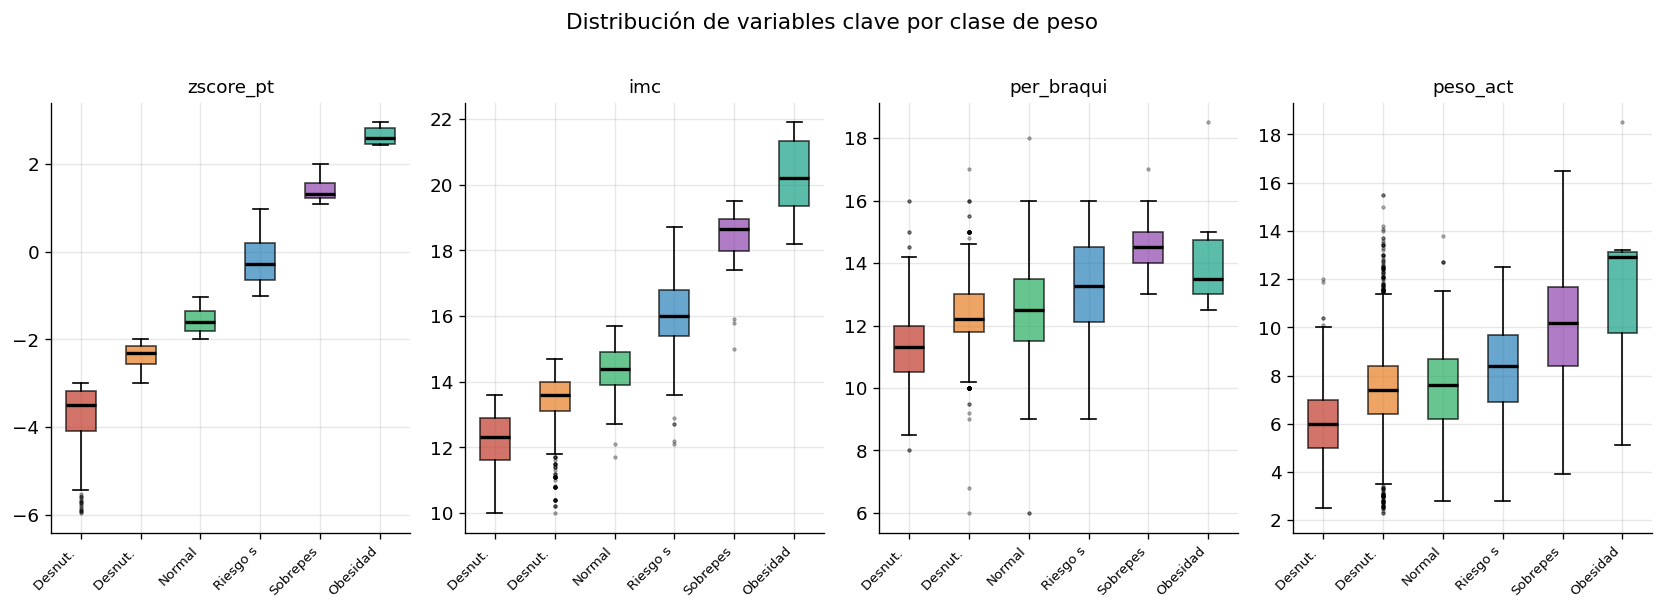

In [21]:
# --- 8c. Boxplots de variables clave por clase de peso ---
vars_box = ['zscore_pt', 'imc', 'per_braqui', 'peso_act']

fig, axes = plt.subplots(1, len(vars_box), figsize=(14, 5))

for ax, var in zip(axes, vars_box):
    grupos = [df.loc[df['clas_peso_label'] == c, var].dropna().values for c in ORDEN]
    bp = ax.boxplot(grupos, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='.', markersize=3, alpha=0.4))
    for patch, color in zip(bp['boxes'], COLORES_LISTA):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(var, fontsize=11)
    ax.set_xticks(range(1, len(ORDEN) + 1))
    ax.set_xticklabels([c[:8] for c in ORDEN], rotation=45, ha='right', fontsize=8)

fig.suptitle('Distribución de variables clave por clase de peso', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## Resumen de hallazgos y notas para el proyecto de grado

| Aspecto | Hallazgo |
|---------|----------|
| **Desbalance de clases** | Más del 85% de los casos presenta desnutrición. Usar `class_weight='balanced'` o SMOTE al entrenar modelos. |
| **Variables más importantes** | `zscore_pt` (r≈0.91) e `imc` (r≈0.79) son los predictores más fuertes de `clas_peso`. |
| **Edad** | Los grupos 6-23 meses concentran la mayor prevalencia de desnutrición severa. |
| **Sexo** | Diferencias leves entre M y F; verificar con prueba chi-cuadrado. |
| **Año** | Evaluar si hay tendencia temporal significativa antes de modelar. |
| **Municipio** | Valledupar concentra el mayor volumen de casos; algunos municipios pequeños muestran tasas de desnutrición más altas. |
| **Nulos en `talla_nac`** | ~60% de valores nulos — evaluar si incluirla o descartarla. |
| **Siguiente paso** | Selección de features → modelos (Random Forest, XGBoost, Logistic Regression) → métricas balanceadas (F1-macro, AUC-ROC). |